In [11]:
import numpy as np
import seaborn as sns

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [5]:
df=pd.read_csv("/content/insurance.csv")

In [13]:
# EDA

In [14]:
df.shape

(1338, 7)

In [15]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [18]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [19]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [23]:
df.columns


dtype('O')

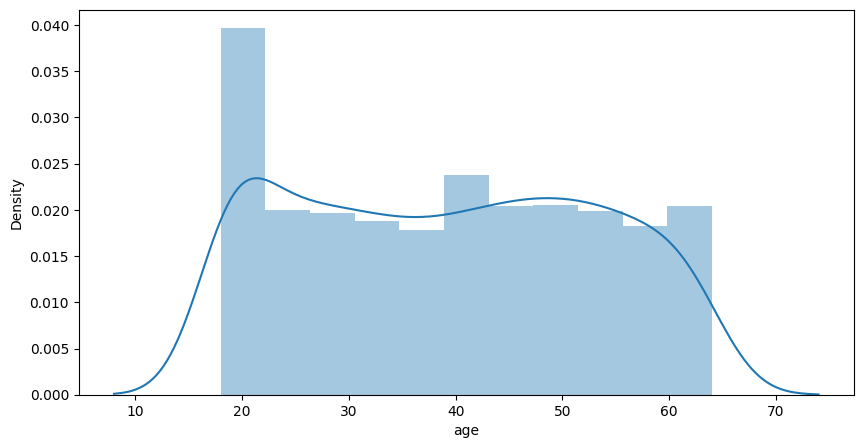

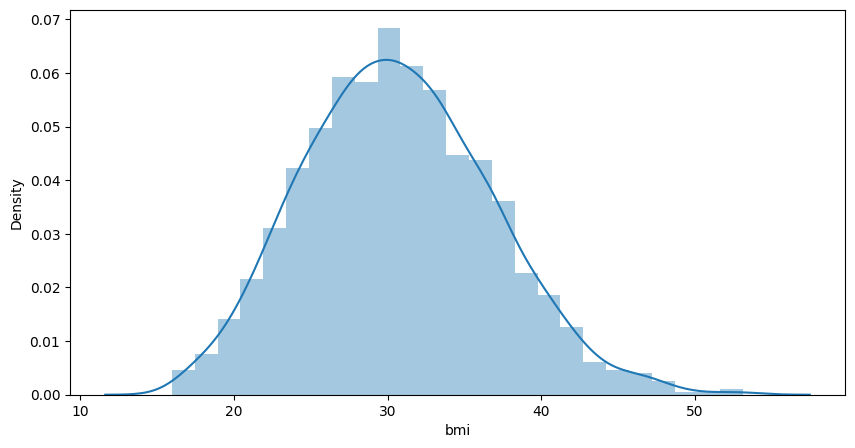

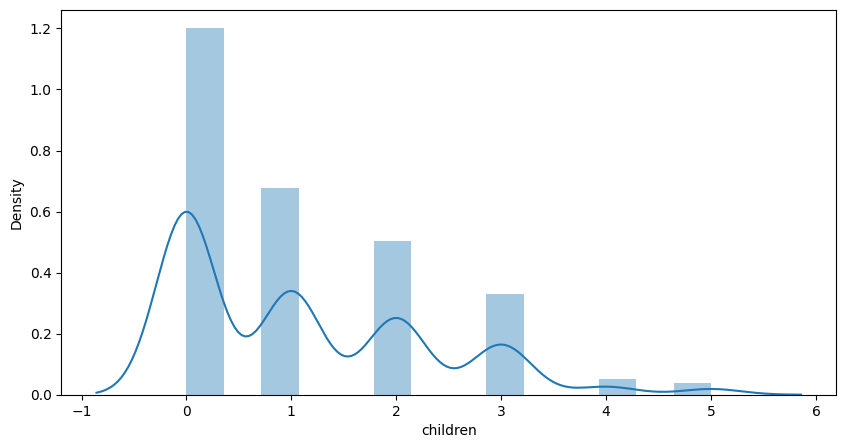

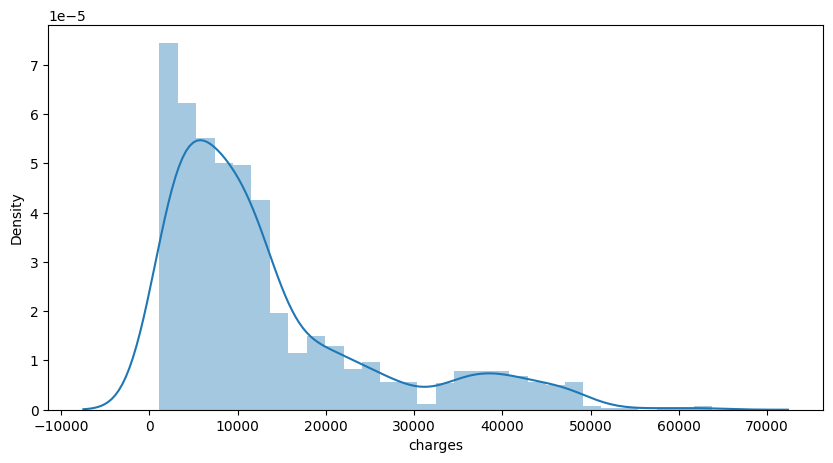

In [25]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
  plt.figure(figsize=(10,5))
  sns.distplot(df[col])
  plt.show()

<Axes: xlabel='sex', ylabel='count'>

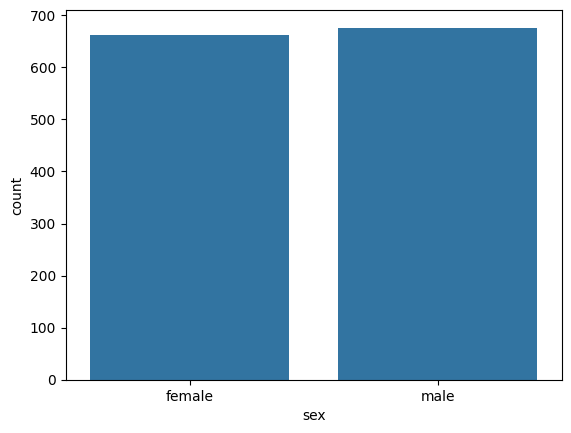

In [28]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

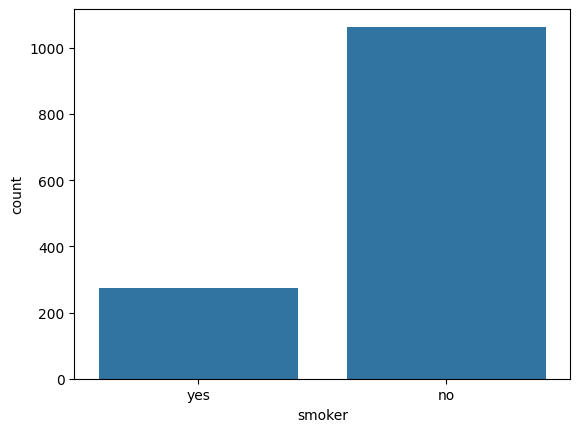

In [30]:
sns.countplot(x =df["smoker"])

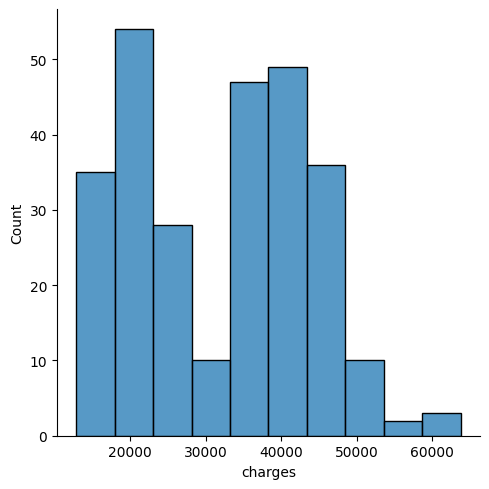

In [33]:
sns.displot(df[df['smoker'] == 'yes']['charges'])

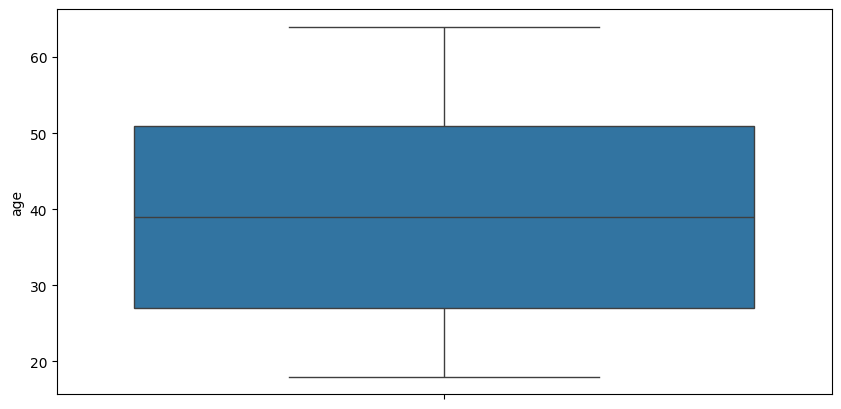

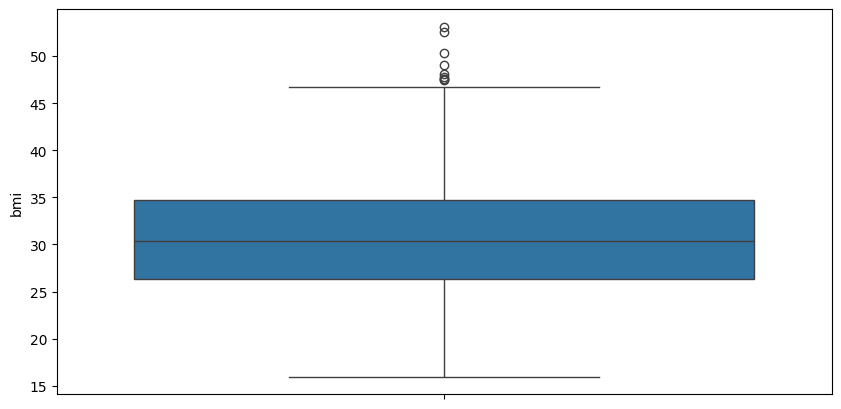

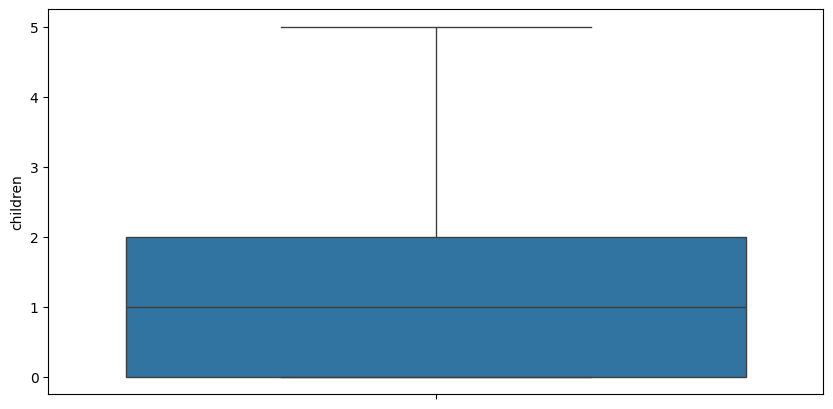

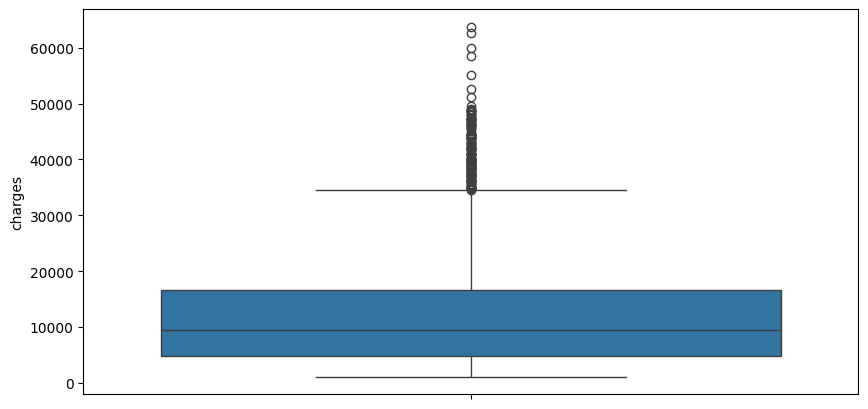

In [34]:
for col in numeric_columns:
  plt.figure(figsize=(10,5))
  sns.boxplot(df[col])
  plt.show()

<Axes: >

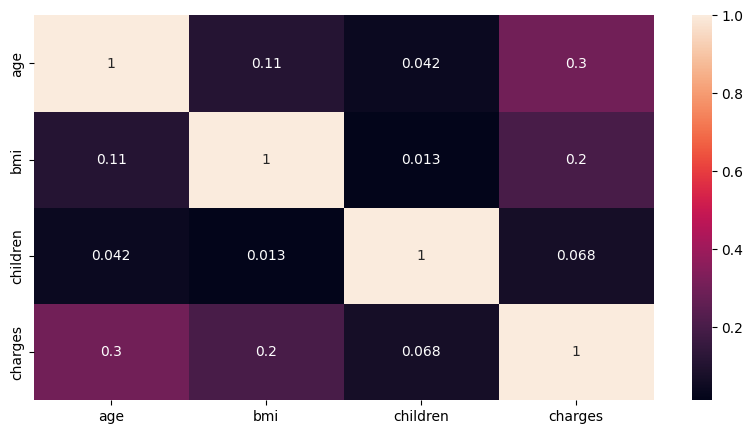

In [37]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)


In [39]:

# Data cleaning and preprocessing

In [41]:
df_cleaned = df.copy()

In [44]:
df_cleaned.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [47]:
df_cleaned.drop_duplicates(inplace = True)

In [48]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [49]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [50]:
# convert into encoded numeric

In [51]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [52]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0,'female':1})

In [53]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [54]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [55]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes':1 , 'no' :0 })

In [56]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [66]:
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=['region']
)

KeyError: "None of [Index(['region'], dtype='object')] are in the [columns]"

In [65]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False
1334,18,1,31.920,0,0,2205.98080,True,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,False,True


In [67]:
# feature engineering and Extraction

In [68]:
df_cleaned['bmi_category'] =pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [69]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,False,True,Overweight
1,18,0,33.770,1,0,1725.55230,False,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,False,True,False,False,Normal
4,32,0,28.880,0,0,3866.85520,False,True,False,False,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False,Obese
1334,18,1,31.920,0,0,2205.98080,True,False,False,False,Obese
1335,18,1,36.850,0,0,1629.83350,False,False,True,False,Obese
1336,21,1,25.800,0,0,2007.94500,False,False,False,True,Overweight


In [70]:
df_cleaned =pd.get_dummies(df_cleaned , columns=['bmi_category'])

In [71]:
df_cleaned

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,False,False,False,True,False,False,True,False
1,18,0,33.770,1,0,1725.55230,False,False,True,False,False,False,False,True
2,28,0,33.000,3,0,4449.46200,False,False,True,False,False,False,False,True
3,33,0,22.705,0,0,21984.47061,False,True,False,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False,False,False,False,True
1334,18,1,31.920,0,0,2205.98080,True,False,False,False,False,False,False,True
1335,18,1,36.850,0,0,1629.83350,False,False,True,False,False,False,False,True
1336,21,1,25.800,0,0,2007.94500,False,False,False,True,False,False,True,False


In [72]:
df_cleaned = df_cleaned.astype(int)

In [73]:
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


In [74]:
# feature scaling